In [3]:
#Import only the basics.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

In [4]:
#Load the dataset.
df = pd.read_csv("../data/raw/1_min_SPY_2008-2021.csv")

In [5]:
#Display the initial rows.
df.head()

,Unnamed: 0,date,open,high,low,close,volume,barCount,average
0,0,20090522 07:30:00,89.45,89.46,89.37,89.37,7872,2102,89.424
1,1,20090522 07:31:00,89.38,89.53,89.37,89.50,5336,1938,89.468
2,2,20090522 07:32:00,89.51,89.54,89.48,89.49,3349,1184,89.516
3,3,20090522 07:33:00,89.49,89.49,89.31,89.34,3495,1240,89.386
4,4,20090522 07:34:00,89.33,89.46,89.33,89.39,9731,2637,89.379


In [6]:
#Check the shape.
df.shape

(2070834, 9)

In [7]:
#Check column names.
df.columns

Index(['Unnamed: 0', 'date', 'open', 'high', 'low', 'close', 'volume',
       'barCount', 'average'],
      dtype='str')

In [8]:
df.dtypes

Unnamed: 0      int64
date              str
open          float64
high          float64
low           float64
close         float64
volume          int64
barCount        int64
average       float64
dtype: object

In [9]:
#Basic information.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2070834 entries, 0 to 2070833
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   date        str    
 2   open        float64
 3   high        float64
 4   low         float64
 5   close       float64
 6   volume      int64  
 7   barCount    int64  
 8   average     float64
dtypes: float64(5), int64(3), str(1)
memory usage: 177.7 MB


In [10]:
#Missing values.
df.isnull().sum()

Unnamed: 0    0
date          0
open          0
high          0
low           0
close         0
volume        0
barCount      0
average       0
dtype: int64

In [11]:
#Duplicates.
df.duplicated().sum()

np.int64(0)

In [12]:
#Summary statistics.
df.describe()

,Unnamed: 0,open,high,low,close,volume,barCount,average
count,2.070834e+06,2.070834e+06,2.070834e+06,2.070834e+06,2.070834e+06,2.070834e+06,2.070834e+06,2.070834e+06
mean,1.035416e+06,2.090970e+02,2.091476e+02,2.090460e+02,2.090970e+02,2.703771e+03,8.388165e+02,2.090969e+02
std,5.977984e+05,8.408773e+01,8.409520e+01,8.407992e+01,8.408770e+01,3.826367e+03,9.743847e+02,8.408758e+01
min,0.000000e+00,6.712000e+01,6.720000e+01,6.710000e+01,6.712000e+01,0.000000e+00,0.000000e+00,6.715200e+01
25%,5.177082e+05,1.331400e+02,1.331700e+02,1.331000e+02,1.331400e+02,6.590000e+02,2.760000e+02,1.331390e+02
50%,1.035416e+06,2.028800e+02,2.029300e+02,2.028300e+02,2.028800e+02,1.503000e+03,5.480000e+02,2.028800e+02
75%,1.553125e+06,2.776300e+02,2.777000e+02,2.775700e+02,2.776300e+02,3.265000e+03,1.055000e+03,2.776340e+02
max,2.070833e+06,4.206700e+02,4.207200e+02,4.204000e+02,4.206700e+02,3.312820e+05,3.024500e+04,4.205350e+02


In [13]:
#Convert the date column.
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2070834 entries, 0 to 2070833
Data columns (total 9 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Unnamed: 0  int64         
 1   date        datetime64[us]
 2   open        float64       
 3   high        float64       
 4   low         float64       
 5   close       float64       
 6   volume      int64         
 7   barCount    int64         
 8   average     float64       
dtypes: datetime64[us](1), float64(5), int64(3)
memory usage: 142.2 MB


In [15]:
#Sort.
df = df.sort_values("date")

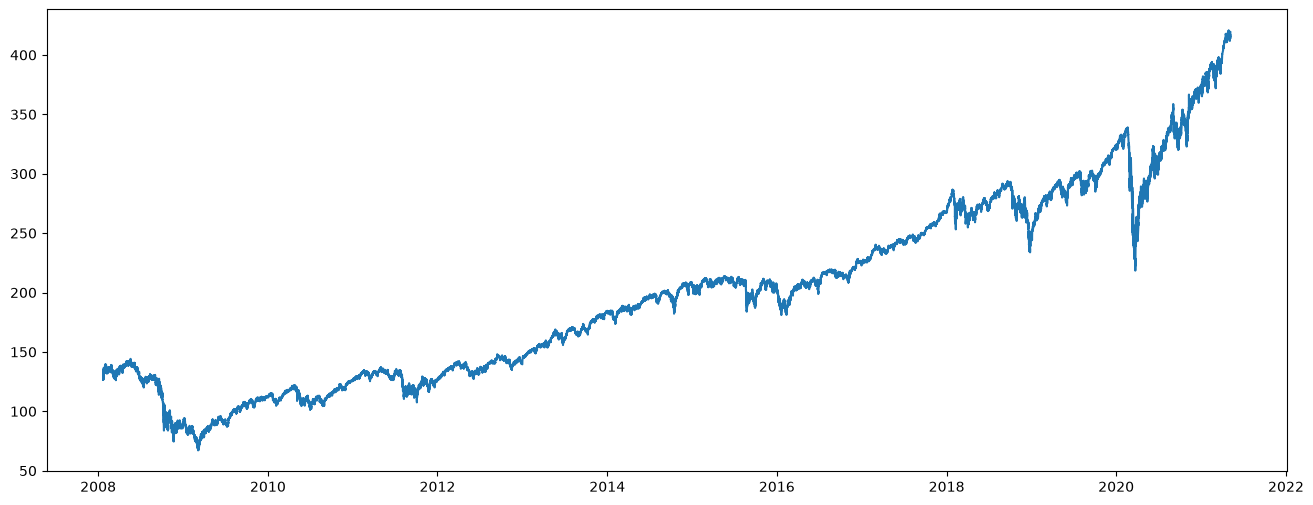

In [16]:
#Visualize closing price.
plt.figure(figsize=(16,6))
plt.plot(df["date"], df["close"])
plt.show()

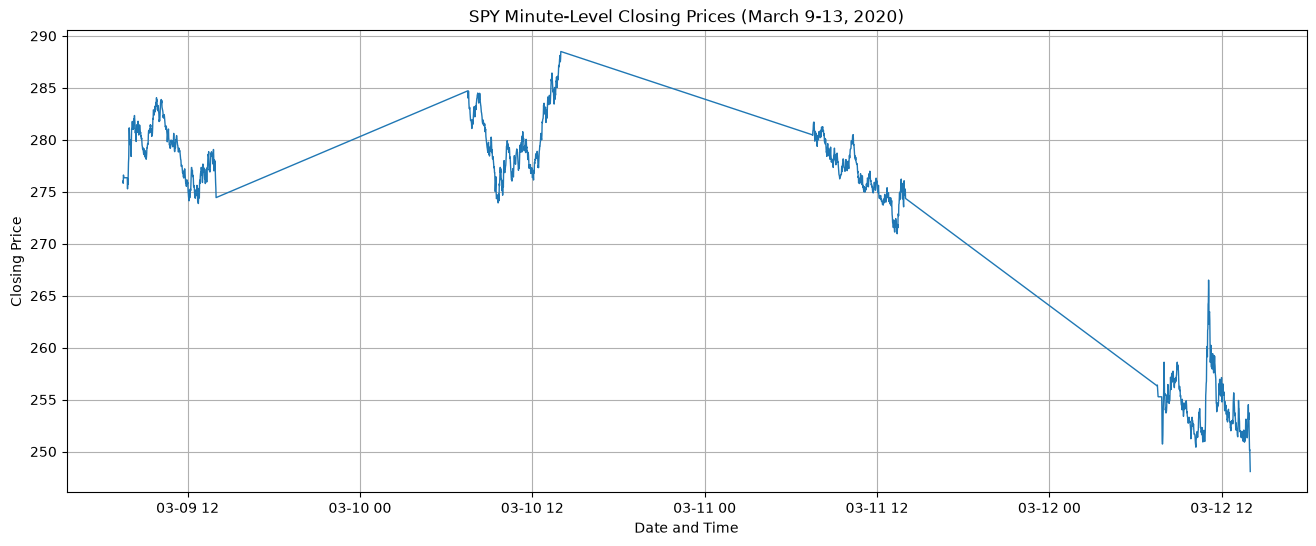

In [17]:
# 1. Define the specific time window (the COVID-19 crash week)
start_date = '2020-03-09'
end_date = '2020-03-13'

# 2. Filter the DataFrame using a boolean mask
mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_zoomed = df.loc[mask]

# 3. Visualize the minute-level closing prices
plt.figure(figsize=(16, 6))
plt.plot(df_zoomed['date'], df_zoomed['close'], linewidth=1)
plt.title('SPY Minute-Level Closing Prices (March 9-13, 2020)')
plt.xlabel('Date and Time')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

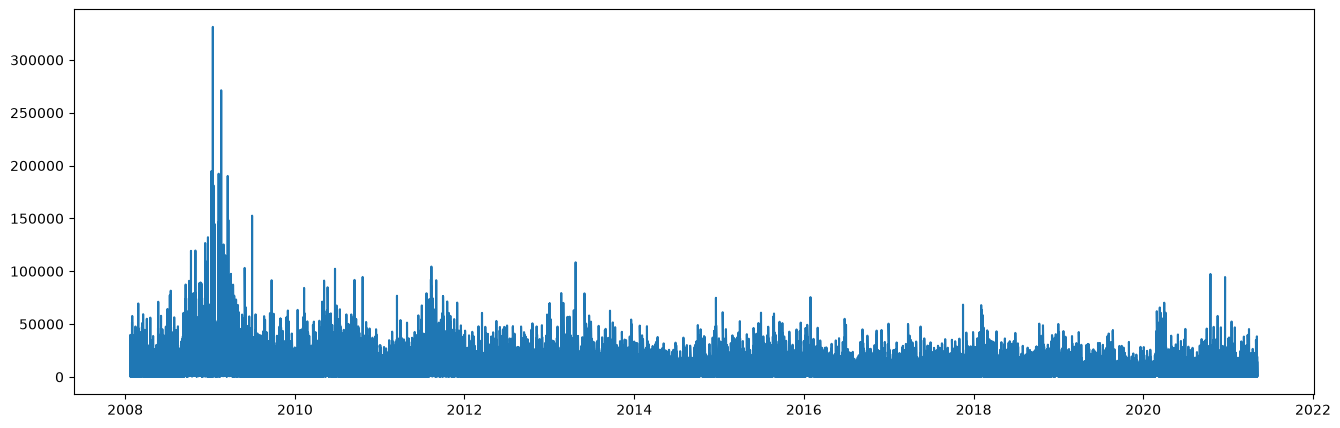

In [18]:
#Visualize closing price.
plt.figure(figsize=(16,5))
plt.plot(df["date"], df["volume"])
plt.show()

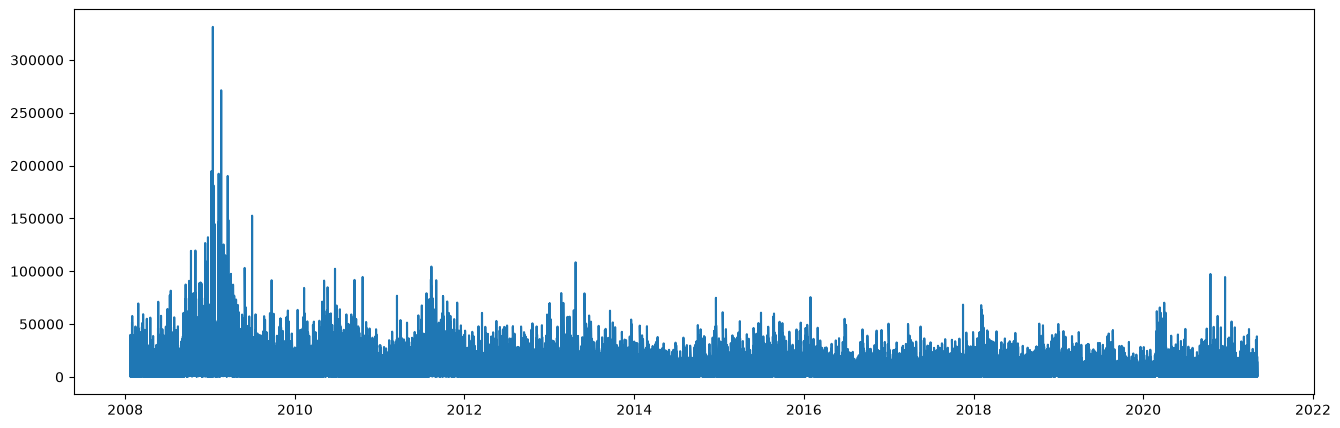

In [30]:
#Visualize volume.
plt.figure(figsize=(16,5))
plt.plot(df["date"], df["volume"])
plt.show()

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'open'}>],
       [<Axes: title={'center': 'high'}>,
        <Axes: title={'center': 'low'}>,
        <Axes: title={'center': 'close'}>],
       [<Axes: title={'center': 'volume'}>,
        <Axes: title={'center': 'barCount'}>,
        <Axes: title={'center': 'average'}>]], dtype=object)

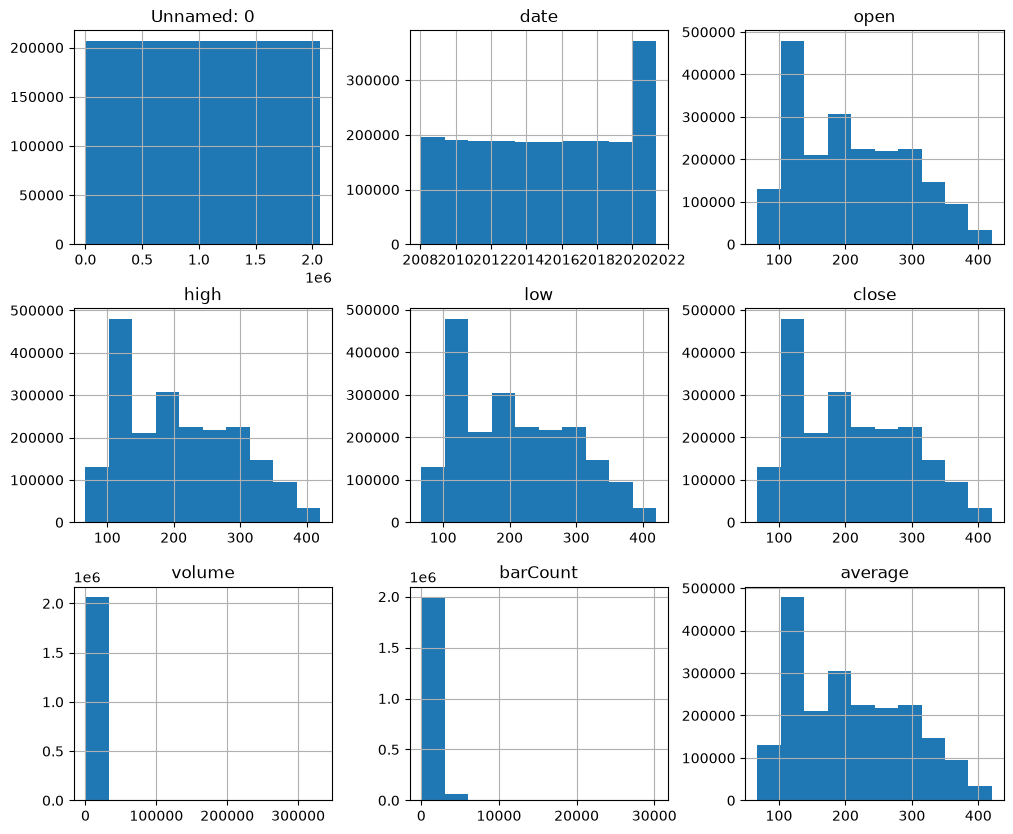

In [ ]:
#Histogram.
df.hist(figsize=(12,10))

<Axes: >

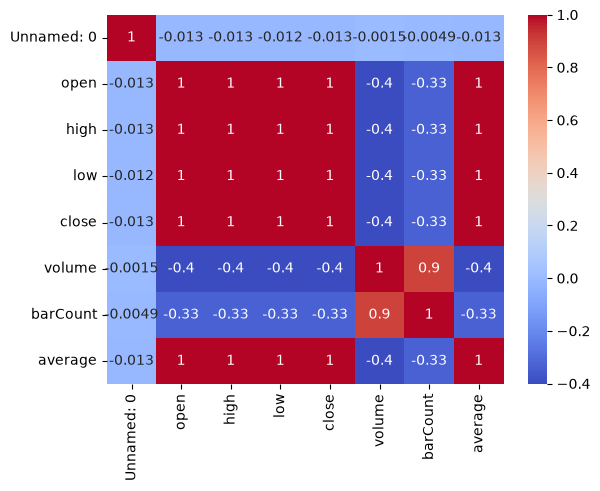

In [ ]:
#Histogram.
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

<Axes: ylabel='close'>

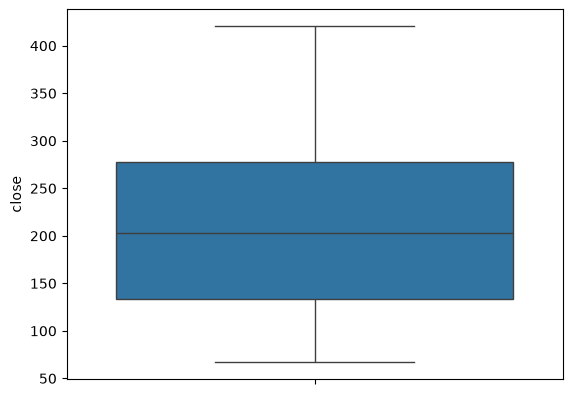

In [ ]:
#Boxplots.
sns.boxplot(data=df["close"])

In [ ]:
#Check the time range.
print(df["date"].min())
print(df["date"].max())

2008-01-22 07:30:00
2021-05-06 13:59:00
